<a href="https://colab.research.google.com/github/nkocjan/computational-intelligence-methods/blob/dev/lab03/lab03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Zadanie 3**

Wymagane importy

In [1]:
#Wymagane importy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.datasets import load_diabetes
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import time
import random
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.neural_network import MLPRegressor
import math

Wczytanie danych z pliku

In [3]:
data = pd.read_csv("Advertising.csv", index_col=0)
X = data.iloc[:,:-1]
y = data.iloc[:, -1]

Plik advertising.csv zawiera w każdym rzędzie informację na temat wydatków na reklamę telewizyjną, reklamową i prasową dla pojedynczego produktu oraz zyski z jego sprzedaży. Można przedstawić zyski jako funkcję  Z(wTV,wradio,wprasa) . Proszę zaproponować architrekturę sieci neuronowej, która dokona aproksymacji tej funkcji i dokonać ewaluacji tej sieci. Proszę porównać wyniki (MSE) dla przynajmniej dwóch różnych struktur jeżeli chodzi o liczbę neuronów i dla dwóch różnych funkcji aktywacji (najlepiej relu i tanh). Proszę pamiętać o podzieleniu zbioru na dane uczące i testujące i o pilnowaniu skali danych.

In [4]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = ~((X < lower_bound) | (X > upper_bound)).any(axis=1)
X = X[mask]
y = y[mask]

print(f"Usunięto {data.shape[0] - X.shape[0]} wartości odstających")

Usunięto 2 wartości odstających


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [6]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X = scaler.transform(X)

Dane przeskalowano

In [7]:
architektury = [(80, 80, 80, 80, 80), (100,100,100), (10,10,10)]
f_aktywacji = ["relu", "tanh"]

for arch in architektury:
  for f in f_aktywacji:
    model = MLPRegressor(solver='adam',hidden_layer_sizes=arch, max_iter = 1000, tol = 0.001, activation = f)
    model.fit(X_train, y_train)

    y_predict =  model.predict(X_test)
    print(f"Model: {arch}, f aktywacji: {f}")
    print(f"Model R^2 score : {model.score(X_train, y_train)}")
    print(f"Model MSE score : {mean_squared_error(y_test, y_predict)} \n")


Model: (80, 80, 80, 80, 80), f aktywacji: relu
Model R^2 score : 0.6449092316875437
Model MSE score : 10.557459737874224 

Model: (80, 80, 80, 80, 80), f aktywacji: tanh
Model R^2 score : 0.005511727182763715
Model MSE score : 27.22470395990151 

Model: (100, 100, 100), f aktywacji: relu
Model R^2 score : 0.37130189178858464
Model MSE score : 16.94973045564361 

Model: (100, 100, 100), f aktywacji: tanh
Model R^2 score : 0.9819834027127923
Model MSE score : 0.37403028414778694 

Model: (10, 10, 10), f aktywacji: relu
Model R^2 score : 0.8613351340688735
Model MSE score : 3.9867945833428857 

Model: (10, 10, 10), f aktywacji: tanh
Model R^2 score : -0.3844141452386378
Model MSE score : 41.45789746688525 



**Zadanie 2**

Dużo zależy od learning rate - dobre do analizy

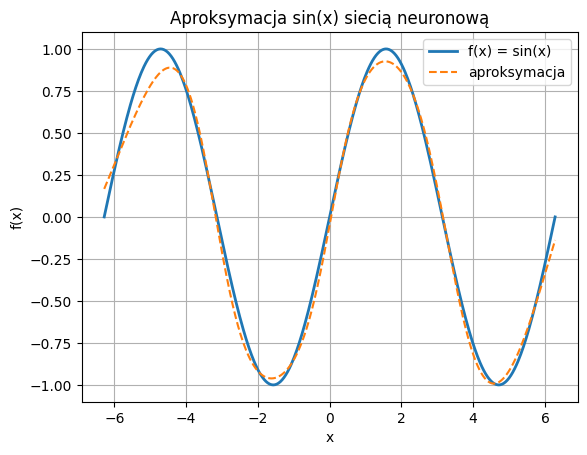

In [11]:
X = np.linspace(-2 * np.pi, 2 * np.pi, 500).reshape(-1, 1)
y = np.sin(X).ravel()
model = MLPRegressor(hidden_layer_sizes=(5), activation='tanh', max_iter=5000, random_state=0, learning_rate_init=0.1)
model.fit(X, y)
y_pred = model.predict(X)

plt.plot(X, y, label='f(x) = sin(x)', linewidth=2)
plt.plot(X, y_pred, label='aproksymacja', linestyle='--')
plt.legend()
plt.title("Aproksymacja sin(x) siecią neuronową")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.show()

weights = model.coefs_
biases = model.intercepts_

In [12]:
print(weights)
print(biases)

[array([[-0.52005372,  0.98412682, -1.10252279, -0.89342701, -0.33923827]]), array([[-1.44862448],
       [-1.54039623],
       [-1.02515351],
       [ 1.45483842],
       [-1.63362417]])]
[array([ 3.13241592,  3.18942925,  0.06934055,  2.96732111, -1.92187176]), array([-0.00960612])]


!!!!!!!!!!!!!!!!!Dodać wzór funkcji aproksymującej

**Zadanie 3**

In [2]:
diabetes = load_diabetes()

In [3]:
X, y = diabetes.data, diabetes.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  random_state=0)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X = scaler.transform(X)

Architektury:

Dorobić funkcję do analizy, potem pet;a

In [18]:
def calculate_metrics(y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return mse, mape, r2

In [19]:
architektury = [(5, 5), (25, 25, 25), (100, 100, 100, 100), (5,5,5,5,5), (200, 200, 200, 200, 200)]
results = []

In [28]:
for arch in architektury:
    model = MLPRegressor(hidden_layer_sizes=arch, activation='relu', max_iter=5000, random_state=0, learning_rate_init=0.1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Obliczanie metryk
    mse, mape, r2 = calculate_metrics(y_test, y_pred)
    results.append((arch, mse, mape, r2))
    print(f"Architektura: {arch}")
    print(f"MSE: {mse:.4f}, MAPE: {mape:.4f}, R²: {r2:.4f}\n")

# Wybór najlepszego modelu (najlepszy R²)
best_arch = max(results, key=lambda x: x[2])  # Maksymalizujemy R²
print(f"Najlepsza architektura: {best_arch[0]} z R² = {best_arch[2]:.4f}")

# Trening najlepszego modelu
best_model = MLPRegressor(hidden_layer_sizes=best_arch[0], activation='relu', max_iter=5000, random_state=0)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

Architektura: (5, 5)
MSE: 3463.1888, MAPE: 0.3857, R²: 0.3246

Architektura: (25, 25, 25)
MSE: 3547.8538, MAPE: 0.3980, R²: 0.3081

Architektura: (100, 100, 100, 100)
MSE: 3510.8700, MAPE: 0.3729, R²: 0.3153

Architektura: (5, 5, 5, 5, 5)
MSE: 3398.3224, MAPE: 0.3529, R²: 0.3373

Architektura: (200, 200, 200, 200, 200)
MSE: 3874.5602, MAPE: 0.4410, R²: 0.2444

Najlepsza architektura: (5, 5, 5, 5, 5) z R² = 0.5313


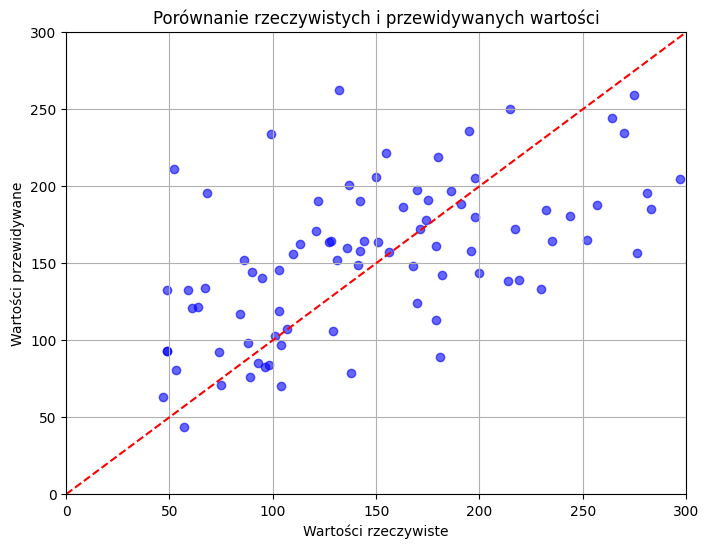

In [30]:
# Wykres porównujący wartości rzeczywiste i przewidywane
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, color='blue', alpha=0.6)
plt.plot([0, 300], [0, 300], color='red', linestyle='--')  # Linia y = x w zakresie od 50 do 100
plt.xlim(0, 300)  # Ustawienie granic dla osi X
plt.ylim(0, 300)  # Ustawienie granic dla osi Y
plt.title("Porównanie rzeczywistych i przewidywanych wartości")
plt.xlabel("Wartości rzeczywiste")
plt.ylabel("Wartości przewidywane")
plt.grid(True)
plt.show()


In [5]:
def calculate_metrics_2(y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return mse, r2

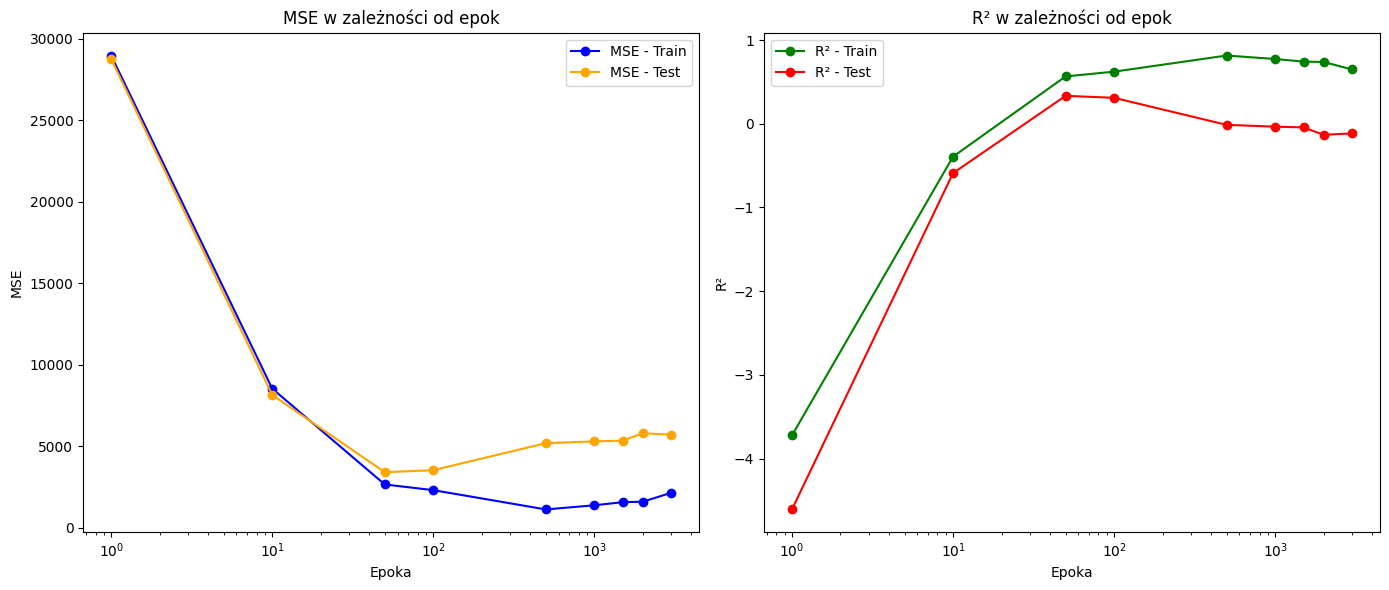

In [8]:
def calculate_metrics(y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return mse, r2

# Model z architekturą (200, 200, 200, 200, 200)
best_model = MLPRegressor(hidden_layer_sizes=(200, 200, 200, 200, 200), activation='relu', max_iter=5000, random_state=0, tol=1e-4, warm_start=True, learning_rate_init=0.001)

# Zbiór epok do analizy
epochs_to_analyze = [1, 10, 50, 100, 500, 1000, 1500, 2000, 3000]

# Listy do przechowywania wyników metryk
train_errors, test_errors = [], []
r2_train, r2_test = [], []

# Pętla przez epoki
for epoch in epochs_to_analyze:
    best_model.max_iter = epoch  # Ustawiamy maksymalną liczbę epok na daną wartość
    best_model.fit(X_train, y_train)

    # Przewidywania na zbiorze treningowym i testowym
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    # Obliczanie MSE i R² dla treningu i testu
    mse_train, r2_train_val = calculate_metrics(y_train, y_train_pred)
    mse_test, r2_test_val = calculate_metrics(y_test, y_test_pred)

    train_errors.append(mse_train)
    test_errors.append(mse_test)
    r2_train.append(r2_train_val)
    r2_test.append(r2_test_val)

# Wykresy: MSE i R² w zależności od epok
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# MSE
ax1.plot(epochs_to_analyze, train_errors, label="MSE - Train", color='blue', marker='o')
ax1.plot(epochs_to_analyze, test_errors, label="MSE - Test", color='orange', marker='o')
ax1.set_title('MSE w zależności od epok')
ax1.set_xlabel('Epoka')
ax1.set_ylabel('MSE')
ax1.set_xscale('log')  # Skala liniowa na osi X
ax1.set_yscale('linear')  # Skala logarytmiczna na osi Y
ax1.legend()

# R²
ax2.plot(epochs_to_analyze, r2_train, label="R² - Train", color='green', marker='o')
ax2.plot(epochs_to_analyze, r2_test, label="R² - Test", color='red', marker='o')
ax2.set_title('R² w zależności od epok')
ax2.set_xlabel('Epoka')
ax2.set_ylabel('R²')
ax2.set_xscale('log')  # Skala liniowa na osi X
ax2.set_yscale('linear')  # Skala logarytmiczna na osi Y
ax2.legend()

plt.tight_layout()
plt.show()

In [10]:
print(best_model.score(X_train, y_train))
print(best_model.score(X_test, y_test))

0.6481266986165678
-0.11637948014571875
